# Análisis de Datos Crudos (Raw Data) de Sensores

Este notebook analiza la estructura de la carpeta `data/raw/` y el archivo `CoordsSensores.csv` para responder a las preguntas clave sobre la viabilidad de usar estos datos en modelos predictivos y su correcta organización.

## 1. ¿Se pueden utilizar para un modelo predictivo?

**Sí, definitivamente**. Son la base del modelo espacio-temporal (LUR). Sin embargo, **no se pueden usar directamente en su estado 'crudo'** por los siguientes motivos:
- **Intervalos de tiempo irregulares**: Algunos sensores envían datos cada 2 mins, otros cada 30 mins.
- **Valores atípicos (outliers)**: Causados por fallos del sensor o condiciones extremas (ej. 100% de humedad que distorsiona las lecturas de PM).
- **Valores nulos**: Huecos en las mediciones que el modelo no aceptará.

Para que un algoritmo de Machine Learning (como Random Forest o Regresión Múltiple) funcione, necesita una matriz de datos limpia y estructurada, por lo que el preprocesamiento previo será obligatorio.

## 2. ¿En caso de tener que generar datos, como tendríamos que hacerlo?

El flujo de trabajo correcto (Pipeline de Ingesta) consta de los siguientes pasos programáticos (algo que podéis hacer con un script como `src/ingesta_sensores.py`):

1. **Recolección**: Iterar sobre todas las carpetas `data_aeternum_*` dentro de `data/raw/` y leer los archivos `.csv` con Pandas.
2. **Unificación**: Concatenar todos los DataFrames individuales en uno solo gigante.
3. **Estandarización Temporal**: Convertir las columnas de fecha a formato estándar `datetime` y "remuestrear" los datos (por ejemplo, calcular la media por cada hora usando `.resample('1H').mean()`).
4. **Limpieza**: Tratar los valores nulos (con métodos de interpolación como `.interpolate(method='linear')`) y eliminar o limitar outliers.
5. **Cruce Espacial**: Hacer un cruce (`merge`) con `CoordsSensores.csv` utilizando la variable `sensor_id` para añadir las coordenadas geográficas (`lat`, `lon`) a todas y cada una de las mediciones.
6. **Exportación**: Guardar el dataset resultante en `data/processed/sensors_cleaned.csv`.

## 3. ¿Cual es la mejor forma de organizar los datos? ¿Carpetas o todo unido?

**Para el modelado y análisis predictivo, la mejor forma es tener TODO UNIDO en un único archivo procesado (ej. `sensors_cleaned.csv`).**

Los algoritmos requieren un único DataFrame (una tabla 2D) de la que extraer características para entrenar. Hacer lecturas en tiempo real de cientos de archivos repartidos en carpetas ralentiza el entrenamiento.

Sin embargo, **las carpetas particionadas (`data_aeternum_...`) se deben MANTENER obligatoriamente en `data/raw/`**. 
Esta estructura dividida por trimestres (como están ahora) es una buena práctica ya que si la red de sensores lanza datos nuevos en el trimestre 2 de 2025, es más fácil volcar esos archivos nuevos en una nueva carpeta (`data_aeternum_2025q2`) que intentar inyectarlos dentro de un archivo CSV masivo y pesado que se podría corromper. De este modo, la carpeta `raw` sirve como almacén histórico seguro e inmutable, y la carpeta `processed` almacena una "copia optimizada y precalculada" lista para analizar.

## 4. Análisis con Código: ¿Cuántos sensores tienen datos desde 2021 hasta 2025?
Podemos analizar las columnas `min_time` (inicio) y `max_time` (fin) del archivo de metadatos `CoordsSensores.csv`.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df_coords = pd.read_csv('data/raw/CoordsSensores.csv')

df_coords['min_time'] = pd.to_datetime(df_coords['min_time'], errors='coerce')
df_coords['max_time'] = pd.to_datetime(df_coords['max_time'], errors='coerce')

sensores_2021_2025 = df_coords[
    (df_coords['min_time'].dt.year <= 2021) & 
    (df_coords['max_time'].dt.year >= 2025)
]

print(f"Total de sensores listados en la red: {len(df_coords)}")
print(f"Sensores que poseen un registro continuo desde 2021 hasta 2025: {len(sensores_2021_2025)}")

display(sensores_2021_2025[['label', 'sensor_id', 'min_time', 'max_time']].head(10))

Total de sensores listados en la red: 68
Sensores que poseen un registro continuo desde 2021 hasta 2025: 16


,label,sensor_id,min_time,max_time
2,LJMU Henry Cotton,f008d1cb8d70,2021-11-02 18:17:59,2025-04-04 13:35:52
3,Old Haymarket,f008d1cb9af0,2021-10-21 17:57:38,2025-04-04 13:41:20
7,Roxby Building,f008d1cbce64,2021-10-21 19:10:38,2025-04-04 13:44:59
9,Liverpool Central station,f008d1cbcecc,2021-10-27 16:18:25,2025-04-04 12:45:34
11,Brunswick station,f008d1cbd028,2021-10-27 16:28:07,2025-04-04 12:44:46
12,Garston,f008d1cbd07c,2021-11-04 17:14:28,2025-03-13 17:08:07
14,St Nicholas Catholic Primary School,f008d1cbdea4,2021-10-21 17:48:55,2025-04-04 13:34:55
15,Everton Valley,f008d1cbdef0,2021-11-04 17:09:02,2025-03-13 17:08:36
17,Anfield,f008d1cbfef4,2021-11-04 16:52:21,2025-04-04 12:44:32
18,Life Sciences Building,f008d1cc02a4,2021-10-21 19:03:31,2025-04-04 13:38:47


### Gráfico de despliegue de sensores
Como métrica adicional, podemos observar visualmente cómo se fue desplegando la red de sensores por año.

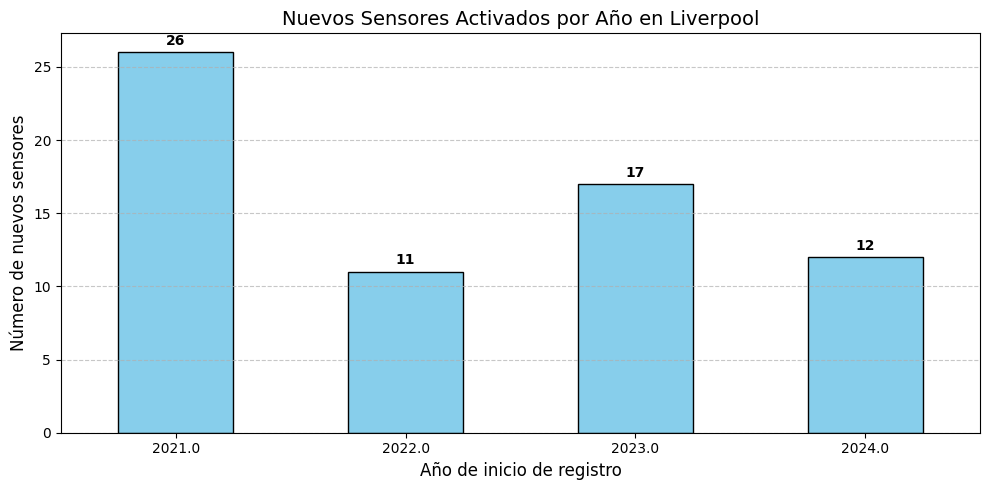

In [11]:
df_coords['start_year'] = df_coords['min_time'].dt.year

activos_por_ano = df_coords['start_year'].value_counts().sort_index()

ax = activos_por_ano.plot(kind='bar', color='skyblue', edgecolor='black', figsize=(10, 5))
ax.set_title("Nuevos Sensores Activados por Año en Liverpool", fontsize=14)
ax.set_xlabel("Año de inicio de registro", fontsize=12)
ax.set_ylabel("Número de nuevos sensores", fontsize=12)

for i, v in enumerate(activos_por_ano):
    ax.text(i, v + 0.5, str(int(v)), ha='center', fontweight='bold')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Pipeline de Ingesta y Limpieza

A continuación, se incluye el script de procesamiento de datos que consolida los sensores válidos (2021-2025), limpia los outliers termodinámicos e interpola los huecos para generar un único archivo maestro listo para su uso.

In [12]:
import pandas as pd
import numpy as np
import os
import glob

# 1. Definir los sensores válidos (los 16 continuos desde 2021 a 2025)
df_coords = pd.read_csv('data/raw/CoordsSensores.csv')
df_coords['min_time'] = pd.to_datetime(df_coords['min_time'], errors='coerce')
df_coords['max_time'] = pd.to_datetime(df_coords['max_time'], errors='coerce')

sensores_validos = df_coords[
    (df_coords['min_time'].dt.year <= 2021) & 
    (df_coords['max_time'].dt.year >= 2025)
]
valid_sensor_ids = set(sensores_validos['sensor_id'])
print(f"Número de sensores válidos a procesar: {len(valid_sensor_ids)}")

# 2. Encontrar todos los archivos CSV en la carpeta data/raw (ignorando CoordsSensores.csv)
# Usar recursividad para buscar en todas las subcarpetas
rutas_archivos = glob.glob('data/raw/**/*.csv', recursive=True)
dfs_a_concatenar = []

print(f"Leyendo {len(rutas_archivos)} archivos localizados...")

# 3. Leer y filtrar por los sensores válidos
for ruta in rutas_archivos:
    nombre_archivo = os.path.basename(ruta)
    if not nombre_archivo.startswith('data_aeternum_'):
        continue
    
    # Extraer el ID correctamente. Ejemplo: data_aeternum_393..._2024...csv
    partes = nombre_archivo.split('_')
    if len(partes) > 2:
        sensor_id = partes[2]
        
        if sensor_id in valid_sensor_ids:
            try:
                temp_df = pd.read_csv(ruta)
                temp_df['sensor_id'] = sensor_id
                dfs_a_concatenar.append(temp_df)
            except Exception as e:
                print(f"Error leyendo {ruta}: {e}")

# 4. Concatenar todo en un único DataFrame masivo
if len(dfs_a_concatenar) > 0:
    df_crudo = pd.concat(dfs_a_concatenar, ignore_index=True)
    print(f"Total de registros cargados: {len(df_crudo)}")
    
    # === ESTANDARIZACIÓN Y LIMPIEZA ===
    
    # Renombrar la columna Date & Time si existe
    if 'Date & Time' in df_crudo.columns:
        df_crudo.rename(columns={'Date & Time': 'datetime'}, inplace=True)
    elif 'date' in df_crudo.columns:
        df_crudo.rename(columns={'date': 'datetime'}, inplace=True)
    
    # a. Convertir a datetime y ordenar
    df_crudo['datetime'] = pd.to_datetime(df_crudo['datetime'], errors='coerce')
    df_crudo = df_crudo.dropna(subset=['datetime'])
    df_crudo = df_crudo.sort_values(by=['sensor_id', 'datetime'])
    
    list_dfs_resampled = []
    
    # b. Limpiar outliers termodinámicos ANTES de interpolar o agregar
    df_crudo.loc[df_crudo['Temperature'] < -20, 'Temperature'] = np.nan
    df_crudo.loc[df_crudo['Temperature'] > 50, 'Temperature'] = np.nan
    df_crudo.loc[df_crudo['Humidity'] > 100, 'Humidity'] = np.nan
    df_crudo.loc[df_crudo['Humidity'] < 0, 'Humidity'] = np.nan
    
    # Procesar sensor por sensor para remuestrear e interpolar
    for sensor in valid_sensor_ids:
        df_sensor = df_crudo[df_crudo['sensor_id'] == sensor].copy()
        
        if len(df_sensor) == 0:
            continue
            
        df_sensor = df_sensor.set_index('datetime')
        
        # REMUESTREO (Agrupar mediciones por cada hora usando la media)
        df_sensor_hora = df_sensor.resample('1h').mean(numeric_only=True)
        
        # INTERPOLACIÓN LINEAL
        # Rellenar huecos pequeños (máximo 3 horas consecutivas perdidas)
        df_sensor_hora = df_sensor_hora.interpolate(method='time', limit=3)
        
        df_sensor_hora['sensor_id'] = sensor
        list_dfs_resampled.append(df_sensor_hora.reset_index())
    
    # Unir todos los sensores procesados
    if len(list_dfs_resampled) > 0:
        df_procesado = pd.concat(list_dfs_resampled, ignore_index=True)
        
        # 5. Cruce Espacial (Añadir latitud, longitud y label)
        df_final = pd.merge(
            df_procesado, 
            df_coords[['sensor_id', 'lat', 'lon', 'label']], 
            on='sensor_id', 
            how='left'
        )
        
        # 6. Guardar el archivo maestro (Sobrescribimos el archivo erróneo)
        os.makedirs('data/interim', exist_ok=True)
        df_final.to_csv('data/interim/sensors_cleaned.csv', index=False)
        
        print("¡Proceso completado exitosamente! Archivo maestro guardado en 'data/interim/sensors_cleaned.csv'.")
        print(df_final.info())
        print("\nVisión general de nulos tras la interpolación:")
        print(df_final.isna().sum())
    else:
        print("No se generó ningún dato tras el remuestreo.")
else:
    print("No se encontraron datos para los sensores válidos. Revisa las subcarpetas raw.")


Número de sensores válidos a procesar: 16
Leyendo 322 archivos localizados...
Total de registros cargados: 809306
¡Proceso completado exitosamente! Archivo maestro guardado en 'data/interim/sensors_cleaned.csv'.
<class 'pandas.DataFrame'>
RangeIndex: 485258 entries, 0 to 485257
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   datetime     485258 non-null  datetime64[us]
 1   Temperature  417616 non-null  float64       
 2   Humidity     383089 non-null  float64       
 3   PM1.0        417638 non-null  float64       
 4   PM2.5        417634 non-null  float64       
 5   PM10         417634 non-null  float64       
 6   sensor_id    485258 non-null  str           
 7   lat          485258 non-null  float64       
 8   lon          485258 non-null  float64       
 9   label        485258 non-null  str           
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 37.0 MB
None

Visión general

## 6. Visualización de Sensores Válidos

Distribución espacial de los 16 sensores aptos para el estudio en Liverpool.

In [13]:
import pandas as pd
import folium

df_coords = pd.read_csv('data/raw/CoordsSensores.csv')
df_coords['min_time'] = pd.to_datetime(df_coords['min_time'], errors='coerce')
df_coords['max_time'] = pd.to_datetime(df_coords['max_time'], errors='coerce')

# Filtrar sensores válidos (2021-2025)
mask = (df_coords['min_time'].dt.year <= 2021) & (df_coords['max_time'].dt.year >= 2025)
validos = df_coords[mask]
descartados = df_coords[~mask]

# Crear mapa centrado en Liverpool usando CartoDB (sin restricción de Referer)
mapa = folium.Map(
    location=[53.41, -2.98],
    zoom_start=12,
    tiles='CartoDB Positron'
)

# Sensores descartados (gris)
for _, row in descartados.iterrows():
    folium.CircleMarker(
        location=[row['lon'], row['lat']],
        radius=5,
        color='grey',
        fill=True,
        fill_opacity=0.4,
        popup=f"{row['label']}<br>ID: {row['sensor_id']}"
    ).add_to(mapa)

# Sensores válidos (rojo)
for _, row in validos.iterrows():
    folium.CircleMarker(
        location=[row['lon'], row['lat']],
        radius=10,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        popup=f"<b>{row['label']}</b><br>ID: {row['sensor_id']}<br>{row['min_time'].strftime('%Y-%m')} → {row['max_time'].strftime('%Y-%m')}",
        tooltip=row['label']
    ).add_to(mapa)

# Guardar como HTML y mostrar en el notebook
mapa.save('C:/Users/Ivan/Ciencia de Datos/PROYIII/outputs/figures/primeros_sensores_liverpool.html')
print("Mapa guardado en 'outputs/figures/primeros_sensores_liverpool.html'")
mapa

Mapa guardado en 'outputs/figures/primeros_sensores_liverpool.html'


## 7. Sensores Candidatos para Análisis Complementario

Más allá de los 16 sensores con cobertura completa (2021-2025), existen otros sensores cuya ventana temporal es más reducida pero que **podrían aportar valor al modelo** si se normalizan adecuadamente. Criterios de selección para candidatos:

- **Mínimo 1 año de datos continuos** para captar estacionalidad.
- **Datos disponibles hasta al menos 2024** (recientes).
- Ubicación geográfica complementaria (zonas no cubiertas por los 16 principales).

Estos sensores se mostrarán en **naranja** en el mapa.

In [14]:
import pandas as pd
import numpy as np
import folium
import glob
import os

df_coords = pd.read_csv('data/raw/CoordsSensores.csv')
df_coords['min_time'] = pd.to_datetime(df_coords['min_time'], errors='coerce')
df_coords['max_time'] = pd.to_datetime(df_coords['max_time'], errors='coerce')

# Calcular años de cobertura (rango temporal bruto)
df_coords['cobertura_anos'] = (df_coords['max_time'] - df_coords['min_time']).dt.days / 365.25

# === CALCULAR MÉTRICA DE CONTINUIDAD ===
# Para cada sensor, leemos sus CSV reales y estimamos qué % de horas
# dentro de su rango [min_time, max_time] tienen al menos 1 registro.

rutas_archivos = glob.glob('data/raw/**/*.csv', recursive=True)

# Construir diccionario: sensor_id -> lista de rutas
sensor_files = {}
for ruta in rutas_archivos:
    nombre = os.path.basename(ruta)
    if not nombre.startswith('data_aeternum_'):
        continue
    partes = nombre.split('_')
    if len(partes) > 2:
        sid = partes[2]
        sensor_files.setdefault(sid, []).append(ruta)

continuidad_dict = {}
registros_totales = {}

for _, row in df_coords.iterrows():
    sid = row['sensor_id']
    if sid not in sensor_files:
        continuidad_dict[sid] = 0.0
        registros_totales[sid] = 0
        continue

    # Leer todos los CSV del sensor
    dfs = []
    for ruta in sensor_files[sid]:
        try:
            temp = pd.read_csv(ruta, usecols=['Date & Time'])
            dfs.append(temp)
        except Exception:
            try:
                temp = pd.read_csv(ruta, usecols=['date'])
                temp.rename(columns={'date': 'Date & Time'}, inplace=True)
                dfs.append(temp)
            except Exception:
                pass

    if not dfs:
        continuidad_dict[sid] = 0.0
        registros_totales[sid] = 0
        continue

    df_sensor = pd.concat(dfs, ignore_index=True)
    df_sensor['datetime'] = pd.to_datetime(df_sensor['Date & Time'], errors='coerce')
    df_sensor = df_sensor.dropna(subset=['datetime'])
    registros_totales[sid] = len(df_sensor)

    if len(df_sensor) == 0:
        continuidad_dict[sid] = 0.0
        continue

    # Redondear a hora para contar horas únicas con datos
    df_sensor['hora'] = df_sensor['datetime'].dt.floor('h')
    horas_con_datos = df_sensor['hora'].nunique()

    # Horas teóricas del rango [min_time, max_time]
    rango_horas = (row['max_time'] - row['min_time']).total_seconds() / 3600
    rango_horas = max(rango_horas, 1)  # evitar div/0

    continuidad = (horas_con_datos / rango_horas) * 100
    continuidad_dict[sid] = round(min(continuidad, 100.0), 1)

df_coords['continuidad_pct'] = df_coords['sensor_id'].map(continuidad_dict)
df_coords['registros_totales'] = df_coords['sensor_id'].map(registros_totales)

print(f"Métrica de continuidad calculada para {len(df_coords)} sensores.")
print()

# --- Clasificación (con filtro de continuidad >= 60%) ---
MIN_CONTINUIDAD = 60  # % mínimo de continuidad para no descartar

mask_validos_base = (df_coords['min_time'].dt.year <= 2021) & (df_coords['max_time'].dt.year >= 2025)
mask_candidatos_base = (
    ~mask_validos_base &
    (df_coords['cobertura_anos'] >= 2.0) &
    (df_coords['max_time'].dt.year >= 2024)
)

# Aplicar filtro de continuidad
mask_validos = mask_validos_base & (df_coords['continuidad_pct'] >= MIN_CONTINUIDAD)
mask_candidatos = mask_candidatos_base & (df_coords['continuidad_pct'] >= MIN_CONTINUIDAD)

validos = df_coords[mask_validos]
candidatos = df_coords[mask_candidatos].sort_values('cobertura_anos', ascending=False)

# Descartados: todo lo que no es válido ni candidato (incluye los que tenían <60% continuidad)
descartados = df_coords[~mask_validos & ~mask_candidatos]

# Sensores eliminados por baja continuidad
eliminados_validos = df_coords[mask_validos_base & ~mask_validos]
eliminados_candidatos = df_coords[mask_candidatos_base & ~mask_candidatos]

print(f"Sensores válidos principales (2021-2025, ≥{MIN_CONTINUIDAD}% cont.): {len(validos)}")
print(f"Sensores candidatos (≥2 años, 2024+, ≥{MIN_CONTINUIDAD}% cont.): {len(candidatos)}")
print(f"Sensores descartados: {len(descartados)}")
print()

if len(eliminados_validos) > 0:
    print(f"⚠️ {len(eliminados_validos)} sensor(es) válido(s) descartado(s) por continuidad <{MIN_CONTINUIDAD}%:")
    display(eliminados_validos[['label', 'sensor_id', 'cobertura_anos', 'continuidad_pct']].reset_index(drop=True))
    print()

if len(eliminados_candidatos) > 0:
    print(f"⚠️ {len(eliminados_candidatos)} candidato(s) descartado(s) por continuidad <{MIN_CONTINUIDAD}%:")
    display(eliminados_candidatos[['label', 'sensor_id', 'cobertura_anos', 'continuidad_pct']].reset_index(drop=True))
    print()

# Tabla de válidos con continuidad
print("=== SENSORES VÁLIDOS (continuidad) ===")
display(validos[['label', 'sensor_id', 'cobertura_anos', 'continuidad_pct', 'registros_totales']].sort_values('continuidad_pct', ascending=False).reset_index(drop=True))
print()

# Tabla de candidatos con continuidad
if len(candidatos) > 0:
    print("=== SENSORES CANDIDATOS ===")
    display(candidatos[['label', 'sensor_id', 'min_time', 'max_time', 'cobertura_anos', 'continuidad_pct', 'registros_totales']].reset_index(drop=True))
else:
    print("No se encontraron sensores candidatos con los criterios establecidos.")

print()
print("Interpretación de continuidad_pct:")
print("  - 100%  = hay al menos 1 registro en cada hora del rango")
print("  - ~70%+ = buena densidad, pocos saltos")
print("  - <50%  = datos muy fragmentados, muchos huecos")

# --- Mapa con 3 categorías ---
mapa = folium.Map(
    location=[53.41, -2.98],
    zoom_start=12,
    tiles='CartoDB Positron'
)

# Descartados (gris)
for _, row in descartados.iterrows():
    folium.CircleMarker(
        location=[row['lon'], row['lat']],
        radius=4,
        color='grey',
        fill=True,
        fill_opacity=0.3,
        popup=f"{row['label']}<br>ID: {row['sensor_id']}<br>Cobertura: {row['cobertura_anos']:.1f} años<br>Continuidad: {row['continuidad_pct']:.0f}%"
    ).add_to(mapa)

# Candidatos (naranja)
for _, row in candidatos.iterrows():
    folium.CircleMarker(
        location=[row['lon'], row['lat']],
        radius=8,
        color='orange',
        fill=True,
        fill_color='orange',
        fill_opacity=0.7,
        popup=f"<b>CANDIDATO: {row['label']}</b><br>ID: {row['sensor_id']}<br>{row['min_time'].strftime('%Y-%m')} → {row['max_time'].strftime('%Y-%m')}<br>Cobertura: {row['cobertura_anos']:.1f} años<br><b>Continuidad: {row['continuidad_pct']:.0f}%</b>",
        tooltip=f"{row['label']} ({row['continuidad_pct']:.0f}%)"
    ).add_to(mapa)

# Válidos (rojo)
for _, row in validos.iterrows():
    folium.CircleMarker(
        location=[row['lon'], row['lat']],
        radius=10,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        popup=f"<b>VÁLIDO: {row['label']}</b><br>ID: {row['sensor_id']}<br>{row['min_time'].strftime('%Y-%m')} → {row['max_time'].strftime('%Y-%m')}<br>Cobertura: {row['cobertura_anos']:.1f} años<br><b>Continuidad: {row['continuidad_pct']:.0f}%</b>",
        tooltip=f"{row['label']} ({row['continuidad_pct']:.0f}%)"
    ).add_to(mapa)

# Leyenda
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 8px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.3); font-family: Arial; font-size: 13px;">
    <b>Sensores de Calidad del Aire</b><br>
    <span style="color:red;">⬤</span> Válidos (2021-2025)<br>
    <span style="color:orange;">⬤</span> Candidatos (≥2 años, hasta 2024+)<br>
    <span style="color:grey;">⬤</span> Descartados<br>
    <hr style="margin: 4px 0;">
    <small>Tooltip muestra % de continuidad</small>
</div>
'''
mapa.get_root().html.add_child(folium.Element(legend_html))

os.makedirs('outputs/figures', exist_ok=True)
mapa.save('outputs/figures/sensores_candidatos_liverpool.html')
print("\nMapa guardado en 'outputs/figures/sensores_candidatos_liverpool.html'")
mapa

Métrica de continuidad calculada para 68 sensores.

Sensores válidos principales (2021-2025, ≥60% cont.): 14
Sensores candidatos (≥2 años, 2024+, ≥60% cont.): 14
Sensores descartados: 40

⚠️ 2 sensor(es) válido(s) descartado(s) por continuidad <60%:


,label,sensor_id,cobertura_anos,continuidad_pct
0,Old Swan,f008d1ccdf20,3.353867,50.3
1,Smithdown Ln,f008d1ccc15c,3.641342,29.9



⚠️ 6 candidato(s) descartado(s) por continuidad <60%:


,label,sensor_id,cobertura_anos,continuidad_pct
0,Williamson Sq.,f008d1cbc690,3.140315,37.8
1,UoL Maths Building,f008d1cbc6b8,3.022587,31.1
2,Queens Square,f008d1cbc8f8,3.028063,44.2
3,Liverpool Tate,f008d1cc11c4,2.527036,9.6
4,Belvedere Academy,f008d1cbc6cc,2.354552,51.0
5,St Francis Academy,f008d1ccc158,2.683094,21.5



=== SENSORES VÁLIDOS (continuidad) ===


,label,sensor_id,cobertura_anos,continuidad_pct,registros_totales
0,Life Sciences Building,f008d1cc02a4,3.449692,95.9,58166
1,St Nicholas Catholic Primary School,f008d1cbdea4,3.449692,95.7,57615
2,Old Haymarket,f008d1cb9af0,3.449692,94.9,57561
3,LJMU Henry Cotton,f008d1cb8d70,3.416838,91.9,55302
4,Liverpool Central station,f008d1cbcecc,3.433265,91.5,51538
5,Everton Valley,f008d1cbdef0,3.351129,90.8,50546
6,Kirkdale station,f008d1cc04ec,3.433265,90.6,51248
7,Roxby Building,f008d1cbce64,3.449692,90.4,64277
8,All Saints Primary,f008d1cc1110,3.340178,90.0,52574
9,Liverpool Tate,f008d1cc0c20,3.433265,89.0,56431



=== SENSORES CANDIDATOS ===


,label,sensor_id,min_time,max_time,cobertura_anos,continuidad_pct,registros_totales
0,Regenerus,f008d1cbcec8,2022-02-07 15:50:49,2025-04-04 13:28:51,3.151266,95.2,53671
1,Bootle Shopping Centre,f008d1cc6928,2022-04-06 11:47:42,2025-04-04 13:36:57,2.995209,72.4,41915
2,Bootle Bus Station,f008d1ccc208,2022-04-06 11:09:47,2025-04-04 13:39:40,2.995209,80.5,44424
3,St Michaels station,f008d1cbcfd4,2021-10-27 17:29:14,2024-09-26 16:07:24,2.913073,87.4,47137
4,Speke DEFRA,f008d1ccc974,2021-10-27 17:24:40,2024-09-26 15:46:02,2.913073,87.9,42744
5,Wavertree RELOVED,f008d1cbd13c,2021-10-27 17:04:49,2024-09-26 15:49:06,2.913073,79.8,40991
6,The Climbing Hangar Sandhills,f008d1cc6f1c,2022-05-06 16:21:56,2025-04-04 13:17:36,2.910335,66.8,31360
7,Alexandra Dock,f008d1cccde4,2022-05-06 16:12:45,2025-04-04 13:16:49,2.910335,90.9,52702
8,Invisible Wind Factory,f008d1cbd4d8,2022-05-06 16:30:44,2025-04-04 12:03:00,2.910335,85.1,40576
9,St Annes St (Kingsway tunnel),f008d1cbc694,2022-07-28 09:13:04,2025-04-04 13:16:48,2.685832,94.8,44473



Interpretación de continuidad_pct:
  - 100%  = hay al menos 1 registro en cada hora del rango
  - ~70%+ = buena densidad, pocos saltos
  - <50%  = datos muy fragmentados, muchos huecos

Mapa guardado en 'outputs/figures/sensores_candidatos_liverpool.html'


## 8. Generación del Dataset Definitivo (`sensors_definitivo.csv`)

Combinamos los **sensores válidos** (2021-2025 con ≥60% continuidad) y los **sensores candidatos** (≥2 años, datos hasta 2024+, ≥60% continuidad) en un único archivo de datos limpio.

### Pipeline de procesamiento:
1. **Lectura**: Cargar todos los CSV crudos de los sensores seleccionados.
2. **Estandarización temporal**: Remuestrear a intervalos regulares de **30 minutos** usando la media.
3. **Limpieza de outliers**: Filtrar temperatura (-20°C < T < 50°C) y humedad (0-100%).
4. **Interpolación temporal**: Rellenar huecos pequeños (≤3 horas) con interpolación lineal basada en tiempo.
5. **Imputación espacial**: Para huecos restantes, usar la media de los **3 sensores más cercanos** que tengan dato en ese instante.
6. **Cruce espacial**: Añadir coordenadas (`lat`, `lon`) y nombre (`label`) desde `CoordsSensores.csv`.
7. **Exportación**: Guardar en `data/processed/sensors_definitivo.csv`.

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
from scipy.spatial.distance import cdist

# PASO 0: Definir sensores definitivos (válidos + candidatos)
# Reutilizamos las variables de la celda anterior.
# 'validos' y 'candidatos' ya están definidos tras ejecutar Cell 13.

sensores_definitivos = pd.concat([validos, candidatos], ignore_index=True)
definitivo_ids = set(sensores_definitivos['sensor_id'])
print(f"Total sensores definitivos: {len(definitivo_ids)}")
print(f"  - Válidos: {len(validos)}")
print(f"  - Candidatos: {len(candidatos)}")
print()

# PASO 1: Leer todos los CSV crudos de los sensores definitivos
rutas_archivos = glob.glob('data/raw/**/*.csv', recursive=True)
dfs_a_concatenar = []

for ruta in rutas_archivos:
    nombre_archivo = os.path.basename(ruta)
    if not nombre_archivo.startswith('data_aeternum_'):
        continue

    partes = nombre_archivo.split('_')
    if len(partes) > 2:
        sensor_id = partes[2]
        if sensor_id in definitivo_ids:
            try:
                temp_df = pd.read_csv(ruta)
                temp_df['sensor_id'] = sensor_id
                dfs_a_concatenar.append(temp_df)
            except Exception as e:
                print(f"Error leyendo {ruta}: {e}")

df_crudo = pd.concat(dfs_a_concatenar, ignore_index=True)
print(f"Registros crudos cargados: {len(df_crudo):,}")

# PASO 2: Estandarizar columna de tiempo
if 'Date & Time' in df_crudo.columns:
    df_crudo.rename(columns={'Date & Time': 'datetime'}, inplace=True)
elif 'date' in df_crudo.columns:
    df_crudo.rename(columns={'date': 'datetime'}, inplace=True)

df_crudo['datetime'] = pd.to_datetime(df_crudo['datetime'], errors='coerce')
df_crudo = df_crudo.dropna(subset=['datetime'])
df_crudo = df_crudo.sort_values(by=['sensor_id', 'datetime'])

# PASO 3: Limpieza de outliers termodinámicos
df_crudo.loc[df_crudo['Temperature'] < -20, 'Temperature'] = np.nan
df_crudo.loc[df_crudo['Temperature'] > 50, 'Temperature'] = np.nan
df_crudo.loc[df_crudo['Humidity'] > 100, 'Humidity'] = np.nan
df_crudo.loc[df_crudo['Humidity'] < 0, 'Humidity'] = np.nan
print(f"Outliers termodinámicos eliminados.")

# PASO 4: Remuestreo a 30 min + Interpolación temporal
numeric_cols = df_crudo.select_dtypes(include=[np.number]).columns.tolist()
if 'sensor_id' in numeric_cols:
    numeric_cols.remove('sensor_id')

list_dfs_resampled = []

for sensor_id in definitivo_ids:
    df_sensor = df_crudo[df_crudo['sensor_id'] == sensor_id].copy()
    if len(df_sensor) == 0:
        print(f"  ⚠️ Sin datos para sensor {sensor_id}")
        continue

    df_sensor = df_sensor.set_index('datetime')

    # Remuestreo a 30 minutos (media)
    df_resampled = df_sensor[numeric_cols].resample('30min').mean()

    # Interpolación lineal (máx 6 slots = 3 horas de huecos)
    df_resampled = df_resampled.interpolate(method='time', limit=6)

    df_resampled['sensor_id'] = sensor_id
    list_dfs_resampled.append(df_resampled.reset_index())

df_procesado = pd.concat(list_dfs_resampled, ignore_index=True)
nulos_pre_espacial = df_procesado[numeric_cols].isna().sum().sum()
print(f"Remuestreo a 30min + interpolación temporal completados.")
print(f"  Nulos restantes antes de imputación espacial: {nulos_pre_espacial:,}")

# PASO 5: Imputación espacial (K=3 sensores más cercanos)
K_VECINOS = 3

# Preparar coordenadas de los sensores definitivos
coords_def = sensores_definitivos[['sensor_id', 'lat', 'lon']].copy()
coords_matrix = coords_def[['lat', 'lon']].values

# Calcular matriz de distancias entre sensores
dist_matrix = cdist(coords_matrix, coords_matrix, metric='euclidean')
np.fill_diagonal(dist_matrix, np.inf)  # no usar el propio sensor

# Para cada sensor, encontrar los K más cercanos
vecinos = {}
for i, sid in enumerate(coords_def['sensor_id'].values):
    indices_cercanos = np.argsort(dist_matrix[i])[:K_VECINOS]
    vecinos[sid] = coords_def.iloc[indices_cercanos]['sensor_id'].values

# Pivot: datetime x sensor_id para cada variable numérica
# Imputar los NaN restantes con la media de los K vecinos
print(f"Imputando huecos con media de {K_VECINOS} sensores más cercanos...")

for col in numeric_cols:
    # Crear pivot table: filas=datetime, columnas=sensor_id
    pivot = df_procesado.pivot_table(index='datetime', columns='sensor_id', values=col, aggfunc='first')

    for sid in definitivo_ids:
        if sid not in pivot.columns:
            continue
        mask_nulos = pivot[sid].isna()
        if mask_nulos.sum() == 0:
            continue

        # Media de los vecinos
        sids_vecinos = [v for v in vecinos.get(sid, []) if v in pivot.columns]
        if len(sids_vecinos) > 0:
            media_vecinos = pivot[sids_vecinos].mean(axis=1)
            pivot.loc[mask_nulos, sid] = media_vecinos[mask_nulos]

    # Unpivot: volver al formato largo
    melted = pivot.reset_index().melt(id_vars='datetime', var_name='sensor_id', value_name=col)
    melted = melted.dropna(subset=[col])

    # Actualizar los valores en df_procesado
    df_procesado = df_procesado.drop(columns=[col]).merge(
        melted, on=['datetime', 'sensor_id'], how='left'
    )

nulos_post = df_procesado[numeric_cols].isna().sum()
print(f"Imputación espacial completada.")
print(f"  Nulos restantes por columna:")
print(nulos_post.to_string())

# PASO 6: Cruce espacial (añadir lat, lon, label)
df_final = pd.merge(
    df_procesado,
    sensores_definitivos[['sensor_id', 'lat', 'lon', 'label']],
    on='sensor_id',
    how='left'
)

# Añadir columna 'tipo' para distinguir
df_final['tipo'] = df_final['sensor_id'].apply(
    lambda x: 'valido' if x in set(validos['sensor_id']) else 'candidato'
)

# PASO 7: Exportar
os.makedirs('data/processed', exist_ok=True)
output_path = 'data/processed/sensors_definitivo.csv'
df_final.to_csv(output_path, index=False)

print(f"\n{'='*60}")
print(f"✅ Dataset definitivo guardado en '{output_path}'")
print(f"   Registros totales: {len(df_final):,}")
print(f"   Sensores: {df_final['sensor_id'].nunique()}")
print(f"   Rango temporal: {df_final['datetime'].min()} → {df_final['datetime'].max()}")
print(f"   Intervalo: 30 minutos")
print(f"   Columnas: {list(df_final.columns)}")
print(f"{'='*60}")
print()
print(df_final.info())
print()
print("Muestra del dataset:")
display(df_final.head(10))

Total sensores definitivos: 28
  - Válidos: 14
  - Candidatos: 14

Registros crudos cargados: 1,313,590
Outliers termodinámicos eliminados.
Remuestreo a 30min + interpolación temporal completados.
  Nulos restantes antes de imputación espacial: 1,017,176
Imputando huecos con media de 3 sensores más cercanos...
Imputación espacial completada.
  Nulos restantes por columna:
Temperature    78990
Humidity       81340
PM1.0          78988
PM2.5          78988
PM10           78988

✅ Dataset definitivo guardado en 'data/processed/sensors_definitivo.csv'
   Registros totales: 1,537,060
   Sensores: 28
   Rango temporal: 2021-03-19 19:30:00 → 2025-03-31 23:30:00
   Intervalo: 30 minutos
   Columnas: ['datetime', 'sensor_id', 'Temperature', 'Humidity', 'PM1.0', 'PM2.5', 'PM10', 'lat', 'lon', 'label', 'tipo']

<class 'pandas.DataFrame'>
RangeIndex: 1537060 entries, 0 to 1537059
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------   

,datetime,sensor_id,Temperature,Humidity,PM1.0,PM2.5,PM10,lat,lon,label,tipo
0,2021-10-27 16:00:00,f008d1cbcecc,18.910,59.410000,1.944211,6.614931,15.613263,-2.97904,53.40413,Liverpool Central station,valido
1,2021-10-27 16:30:00,f008d1cbcecc,18.902,59.475000,1.926368,6.551455,15.576972,-2.97904,53.40413,Liverpool Central station,valido
2,2021-10-27 17:00:00,f008d1cbcecc,18.894,59.540000,1.908525,6.487980,15.540681,-2.97904,53.40413,Liverpool Central station,valido
3,2021-10-27 17:30:00,f008d1cbcecc,18.886,59.605000,1.890682,6.424505,15.504390,-2.97904,53.40413,Liverpool Central station,valido
4,2021-10-27 18:00:00,f008d1cbcecc,18.878,59.670000,1.872839,6.361030,15.468098,-2.97904,53.40413,Liverpool Central station,valido
5,2021-10-27 18:30:00,f008d1cbcecc,18.870,59.735000,1.854996,6.297555,15.431807,-2.97904,53.40413,Liverpool Central station,valido
6,2021-10-27 19:00:00,f008d1cbcecc,18.862,59.800000,1.837153,6.234080,15.395516,-2.97904,53.40413,Liverpool Central station,valido
7,2021-10-27 19:30:00,f008d1cbcecc,15.635,84.126429,1.443861,5.661638,15.742952,-2.97904,53.40413,Liverpool Central station,valido
8,2021-10-27 20:00:00,f008d1cbcecc,15.590,83.970714,1.364850,6.429133,18.686646,-2.97904,53.40413,Liverpool Central station,valido
9,2021-10-27 20:30:00,f008d1cbcecc,15.695,83.615000,1.391685,6.502387,21.782063,-2.97904,53.40413,Liverpool Central station,valido
